# Chapter 76 — Discrete Dynamical Systems

> **Prerequisites:** ch075 (Recursion), ch074 (Iterative Computation)
>
> **You will learn:**
> - Define discrete dynamical systems as iterated maps
> - Find and classify fixed points and periodic orbits
> - Simulate 1D and 2D systems
> - Connect to time series models (AR processes) and population dynamics
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **discrete dynamical system** is a rule for updating a state over discrete time steps:
xₙ₊₁ = f(xₙ)

The sequence x₀, x₁, x₂, ... is called the **orbit** or **trajectory** of x₀ under f.

Key behaviors:
- **Fixed point:** x* where f(x*) = x* — system stays there forever
- **Periodic orbit:** sequence that repeats with period k: x_{n+k} = xₙ for all n
- **Attracting fixed point:** nearby orbits converge to x*; |f'(x*)| < 1
- **Repelling fixed point:** nearby orbits diverge from x*; |f'(x*)| > 1
- **Chaos:** sensitive dependence on initial conditions; non-periodic, non-converging

**Applications:**
- Population models: xₙ₊₁ = r·xₙ·(1 - xₙ) — logistic map
- Time series: AR(1) model: xₙ = a·xₙ₋₁ + εₙ
- Optimization: gradient descent is a dynamical system on parameter space
- Neural network training: each step is an iteration of the dynamical system

---

## 2. Intuition & Mental Models

**Physical analogy:** A bouncing ball. At each bounce, the height is some fraction r of the previous height: hₙ₊₁ = r·hₙ. This is a discrete dynamical system. The fixed point is h=0 (ball on ground). With r < 1, all orbits converge to the fixed point.

**Computational analogy:** A recurrent neural network (RNN) at inference time is a discrete dynamical system: hidden state hₙ₊₁ = f(W·hₙ + U·xₙ + b). Each token processed is one step of the system.

---

## 3. Visualization

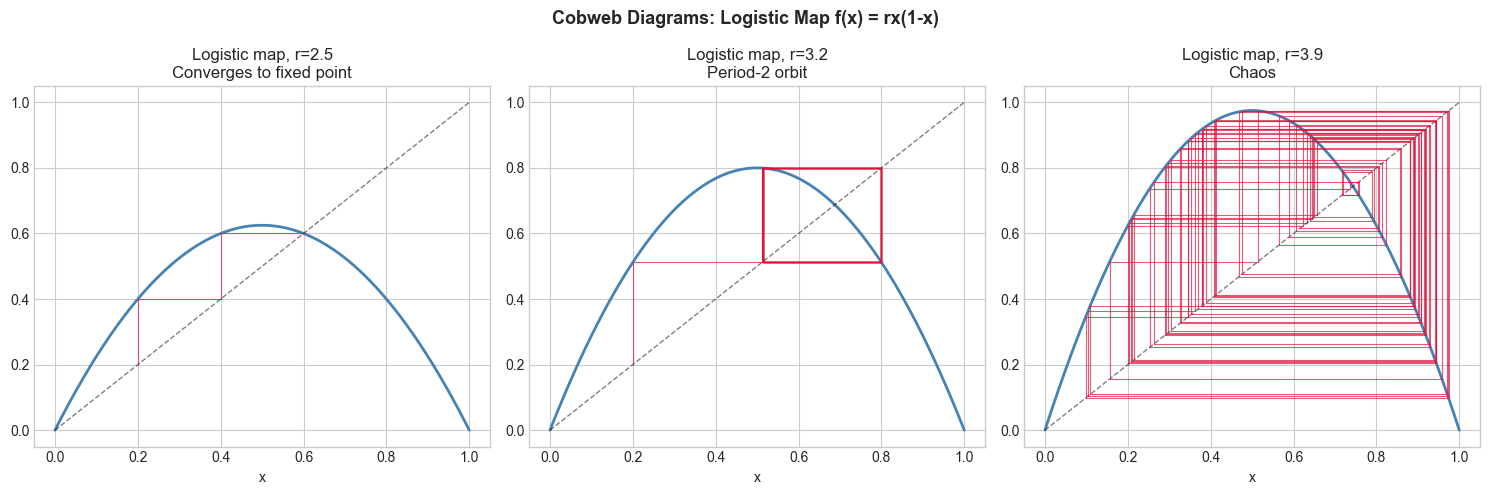

In [1]:
# --- Visualization: Orbit diagrams and cobweb plots ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def cobweb(f, x0, n_steps, ax, x_min=0, x_max=1, color='crimson'):
    """Draw cobweb diagram for f starting at x0."""
    x = np.linspace(x_min, x_max, 400)
    ax.plot(x, f(x), color='steelblue', linewidth=2)
    ax.plot(x, x, 'k--', linewidth=1, alpha=0.5)  # y=x line
    xi = x0
    for _ in range(n_steps):
        yi = f(xi)
        ax.plot([xi, xi], [xi, yi], color=color, linewidth=0.8, alpha=0.7)
        ax.plot([xi, yi], [yi, yi], color=color, linewidth=0.8, alpha=0.7)
        xi = yi

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# r=2.5: convergence to fixed point
r = 2.5
f25 = lambda x: r*x*(1-x)
cobweb(f25, 0.2, 30, axes[0])
axes[0].set_title(f'Logistic map, r={r}\nConverges to fixed point'); axes[0].set_xlabel('x')

# r=3.2: period-2 orbit
r = 3.2
f32 = lambda x: r*x*(1-x)
cobweb(f32, 0.2, 50, axes[1])
axes[1].set_title(f'Logistic map, r={r}\nPeriod-2 orbit'); axes[1].set_xlabel('x')

# r=3.9: chaos
r = 3.9
f39 = lambda x: r*x*(1-x)
cobweb(f39, 0.2, 80, axes[2])
axes[2].set_title(f'Logistic map, r={r}\nChaos'); axes[2].set_xlabel('x')

plt.suptitle('Cobweb Diagrams: Logistic Map f(x) = rx(1-x)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Discrete dynamical system simulator ---
import numpy as np

def simulate_dynamical_system(f, x0, n_steps):
    """
    Simulate the dynamical system xₙ₊₁ = f(xₙ).
    
    Args:
        f: callable, the update rule
        x0: initial state (scalar or array)
        n_steps: int, number of iterations
    Returns:
        np.ndarray of shape (n_steps+1, ...) containing the orbit
    """
    x0 = np.asarray(x0, dtype=float)
    orbit = [x0]
    x = x0.copy()
    for _ in range(n_steps):
        x = f(x)
        orbit.append(x.copy())
    return np.array(orbit)

def find_fixed_points(f, x_grid, tol=1e-6):
    """Find approximate fixed points by locating where f(x) ≈ x."""
    diff = f(x_grid) - x_grid
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    return x_grid[sign_changes]

# Logistic map analysis
R_VALUES = [1.5, 2.5, 3.2, 3.5, 3.9]
print("Logistic map long-term behavior:")
for r in R_VALUES:
    f = lambda x, r=r: r*x*(1-x)
    orbit = simulate_dynamical_system(f, 0.3, 500)
    tail = orbit[-50:]  # last 50 steps (after transient)
    unique_vals = np.unique(tail.round(4))
    if len(unique_vals) <= 4:
        print(f"  r={r}: attractor at {unique_vals}")
    else:
        print(f"  r={r}: chaos ({len(unique_vals)} unique values in last 50 steps)")

Logistic map long-term behavior:
  r=1.5: attractor at [0.3333]
  r=2.5: attractor at [0.6]
  r=3.2: attractor at [0.513  0.7995]
  r=3.5: attractor at [0.3828 0.5009 0.8269 0.875 ]
  r=3.9: chaos (49 unique values in last 50 steps)


---

## 6. Experiments

**Experiment 1:** Run the logistic map for r from 2 to 4 in steps of 0.01. Plot the long-term behavior (orbit tail) as a bifurcation diagram. This is one of the most famous pictures in mathematics.

**Experiment 2:** Simulate a 2D system: xₙ₊₁ = r·xₙ·(1-xₙ-αyₙ), yₙ₊₁ = s·yₙ·(1-yₙ-βxₙ). This is a competitive Lotka-Volterra model. Vary α and β and observe coexistence vs extinction.

---

## 7. Exercises

**Easy 1.** The map xₙ₊₁ = 0.9·xₙ + 1 has a fixed point. Find it analytically and verify by simulating.

**Easy 2.** Simulate xₙ₊₁ = cos(xₙ) starting at x₀=1 for 100 steps. What value does it converge to? This is the Dottie number.

**Medium 1.** Implement a bifurcation diagram for the logistic map: for each r in [2.5, 4.0], simulate 500 steps, discard first 400, plot the last 100. Plot all (r, x) pairs together.

**Medium 2.** For the logistic map with r=3.9, show sensitive dependence: simulate two orbits starting at x₀=0.500 and x₀=0.501. Plot |difference| vs time on a log scale.

**Hard.** Implement the Lyapunov exponent for a 1D map: λ = lim_{n→∞} (1/n) Σᵢ log|f'(xᵢ)|. For the logistic map, compute λ for r from 2 to 4. λ > 0 indicates chaos. Verify your bifurcation diagram and Lyapunov exponent match.

---

## 9. Chapter Summary & Connections

- Discrete dynamical systems: xₙ₊₁ = f(xₙ) — the orbit is the sequence of states
- Fixed points: f(x*)=x*; stable if |f'(x*)| < 1
- Logistic map exhibits period doubling, chaos, sensitive dependence
- Machine learning training is a dynamical system on parameter space

**Forward connections:**
- ch077 (Chaos) deepens the analysis with Lyapunov exponents and bifurcation diagrams
- ch082 (Predator-Prey Project) uses 2D discrete dynamical systems
- AR(1) time series models in ch285 are linear discrete dynamical systems